# Checkpoint 4 — Differentiated Problem Solving
## Análise de Desempenho de uma API sob Carga

**Aluno:** Henrique
**FIAP**

---

## 1. Contexto e Modelagem

### O problema

Uma API foi testada com cargas crescentes (requisições por segundo), medindo o tempo médio de resposta em cada carga. A capacidade máxima teórica dessa API é de **50 requisições por segundo**.

### Variáveis

| Variável | O que representa | Unidade |
|---|---|---|
| x | Carga (requisições por segundo) | req/s |
| T(x) | Tempo médio de resposta | ms |

Domínio válido: **0 ≤ x < 50** (a carga não pode ser negativa nem chegar a 50, que é o limite da API).

### Dados do teste de carga

| Carga (req/s) | Tempo de resposta (ms) |
|---|---|
| 10 | 25 |
| 20 | 33 |
| 30 | 50 |
| 35 | 67 |
| 40 | 100 |
| 45 | 200 |
| 48 | 500 |

O tempo cresce devagar no começo, mas quando a carga chega perto de 50 req/s, o tempo dispara.

### A função escolhida

Uma reta ou uma parábola não servem aqui, porque nunca "explodem" — elas crescem, mas de forma suave. Precisamos de uma função que cresça cada vez mais rápido conforme x se aproxima de 50. Por isso usamos uma **função racional** (uma fração), que tem uma **assíntota vertical** em x = 50:

$$T(x) = \frac{1000}{50 - x}$$

Testando essa fórmula com os dados reais (célula de código abaixo), ela bate certinho com praticamente todos os pontos.

### Por que essa função faz sentido?

É parecido com o que acontece com qualquer recurso de infraestrutura (CPU, banco de dados, conexões) perto do limite: cada nova requisição precisa "esperar a vez", e quanto mais perto do limite máximo, mais requisições ficam na fila esperando. Por isso o tempo não cresce de forma linear — ele cresce cada vez mais rápido, até "explodir" perto da capacidade máxima.

### 50 req/s é um valor seguro para operar?

**Não.** 50 req/s é só o limite teórico — um valor que o sistema nunca deveria realmente alcançar. Na prática, o sistema já fica lento e instável bem antes disso (em 48 req/s o tempo já é de 500 ms!). Operar perto desse limite é arriscado.

## 2. Análise com Limites (SymPy)

Agora vamos usar a biblioteca **SymPy** para definir a função matematicamente e calcular os limites pedidos.

In [1]:
import sympy as sp

x = sp.symbols('x')      # carga (variavel independente)
T = 1000 / (50 - x)      # tempo de resposta previsto pelo modelo

T

1000/(50 - x)

In [2]:
cargas = [10, 20, 30, 35, 40, 45, 48]
tempos_reais = [25, 33, 50, 67, 100, 200, 500]

for carga, real in zip(cargas, tempos_reais):
    modelo = T.subs(x, carga)
    print(f"Carga = {carga} req/s  |  Real = {real} ms  |  Modelo = {float(modelo):.1f} ms")

Carga = 10 req/s  |  Real = 25 ms  |  Modelo = 25.0 ms
Carga = 20 req/s  |  Real = 33 ms  |  Modelo = 33.3 ms
Carga = 30 req/s  |  Real = 50 ms  |  Modelo = 50.0 ms
Carga = 35 req/s  |  Real = 67 ms  |  Modelo = 66.7 ms
Carga = 40 req/s  |  Real = 100 ms  |  Modelo = 100.0 ms
Carga = 45 req/s  |  Real = 200 ms  |  Modelo = 200.0 ms
Carga = 48 req/s  |  Real = 500 ms  |  Modelo = 500.0 ms


### Calculando os limites

Vamos calcular o que acontece com T(x) quando x se aproxima de 50 pela esquerda, e quando x se aproxima de 0.

In [3]:
limite_50 = sp.limit(T, x, 50, '-')
limite_0 = sp.limit(T, x, 0)

print("Limite quando x -> 50 (pela esquerda):", limite_50)
print("Limite quando x -> 0:", limite_0)

Limite quando x -> 50 (pela esquerda): oo
Limite quando x -> 0: 20


### O que esses limites significam?

- **Quando x → 50⁻, T(x) → ∞:** confirma que existe uma assíntota vertical em x = 50. O tempo de resposta cresce sem parar conforme a carga se aproxima do limite máximo.
- **Quando x → 0, T(x) = 20 ms:** mesmo com quase nenhuma carga, existe um tempo mínimo de resposta — o tempo básico de rede e processamento que sempre existe.

**Existe uma descontinuidade?** Sim. Em x = 50 a função não é definida (seria uma divisão por zero).

**O que isso significa na prática?** A função é matematicamente válida para qualquer x entre 0 e 50 — dá pra calcular, por exemplo, T(49.9), e o resultado é um número gigante (10.000 ms). Só que, na vida real, o sistema não aguentaria chegar tão perto do limite: antes disso os usuários já teriam desistido, ou o sistema já teria caído. Ou seja: **matematicamente a função existe até quase 50, mas operacionalmente o sistema já está inutilizável bem antes disso.**

## 3. Simulação e Visualização

Vamos calcular o tempo de resposta para várias cargas, incluindo valores bem perto do limite (49, 49.5 e 49.9 req/s), e depois montar um gráfico.

In [4]:
def tempo_resposta(carga):
    return 1000 / (50 - carga)

cargas_simuladas = [10, 20, 30, 40, 45, 48, 49, 49.5, 49.9]

for c in cargas_simuladas:
    print(f"Carga = {c} req/s  ->  Tempo = {tempo_resposta(c):.1f} ms")

Carga = 10 req/s  ->  Tempo = 25.0 ms
Carga = 20 req/s  ->  Tempo = 33.3 ms
Carga = 30 req/s  ->  Tempo = 50.0 ms
Carga = 40 req/s  ->  Tempo = 100.0 ms
Carga = 45 req/s  ->  Tempo = 200.0 ms
Carga = 48 req/s  ->  Tempo = 500.0 ms
Carga = 49 req/s  ->  Tempo = 1000.0 ms
Carga = 49.5 req/s  ->  Tempo = 2000.0 ms
Carga = 49.9 req/s  ->  Tempo = 10000.0 ms


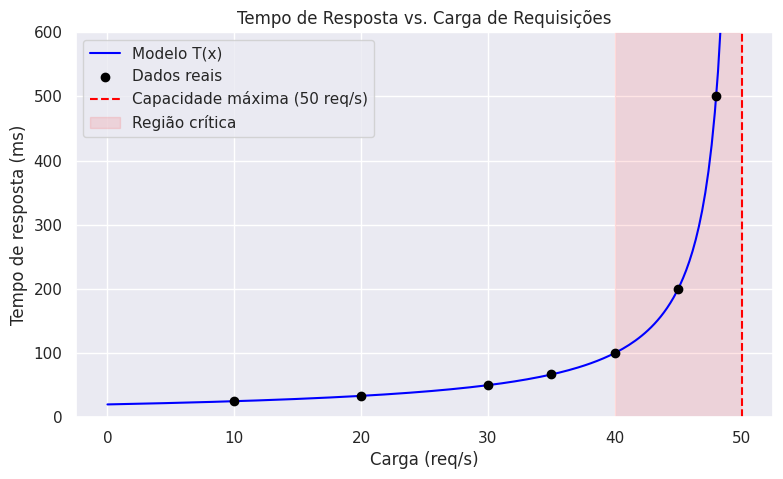

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")

cargas_reais = [10, 20, 30, 35, 40, 45, 48]
tempos_reais = [25, 33, 50, 67, 100, 200, 500]

x_valores = np.linspace(0, 49.9, 200)
y_valores = tempo_resposta(x_valores)

plt.figure(figsize=(9, 5))

plt.plot(x_valores, y_valores, label="Modelo T(x)", color="blue")
plt.scatter(cargas_reais, tempos_reais, color="black", label="Dados reais", zorder=5)
plt.axvline(x=50, color="red", linestyle="--", label="Capacidade máxima (50 req/s)")
plt.axvspan(40, 50, color="red", alpha=0.1, label="Região crítica")

plt.title("Tempo de Resposta vs. Carga de Requisições")
plt.xlabel("Carga (req/s)")
plt.ylabel("Tempo de resposta (ms)")
plt.ylim(0, 600)
plt.legend()
plt.show()

## 4. Aplicação Streamlit

Esta célula usa `%%writefile` para criar um arquivo `app.py` com uma versão interativa do modelo, usando Streamlit.

Para rodar: abra um terminal na pasta do notebook e digite `streamlit run app.py`.

In [6]:
%%writefile app.py
import streamlit as st
import numpy as np
import matplotlib.pyplot as plt

def tempo_resposta(x):
    return 1000 / (50 - x)

st.title("Simulador de Saturação de API")
st.write("Este app mostra como o tempo de resposta de uma API cresce conforme a carga se aproxima da capacidade máxima de 50 requisições por segundo.")

carga = st.slider("Carga (requisições por segundo)", 0, 49, 25)

tempo = tempo_resposta(carga)
st.write(f"**Tempo de resposta estimado:** {tempo:.1f} ms")

if tempo > 200:
    st.error("Tempo de resposta muito alto! O sistema está perto da saturação.")
elif carga >= 40:
    st.warning("Atenção: a carga está na região crítica (acima de 40 req/s).")
else:
    st.success("Sistema operando normalmente.")

x_valores = np.linspace(0, 49.9, 200)
y_valores = tempo_resposta(x_valores)

fig, ax = plt.subplots()
ax.plot(x_valores, y_valores, label="Modelo T(x)")
ax.axvline(x=50, color="red", linestyle="--", label="Capacidade máxima (50 req/s)")
ax.scatter([carga], [tempo], color="orange", s=100, zorder=5, label="Carga escolhida")
ax.set_xlabel("Carga (req/s)")
ax.set_ylabel("Tempo de resposta (ms)")
ax.set_ylim(0, 1100)
ax.legend()

st.pyplot(fig)

Writing app.py


## 5. Relatório Final

### Qual comportamento matemático mostra a saturação?

O tempo de resposta cresce de forma cada vez mais rápida conforme a carga aumenta — isso é o comportamento de uma **assíntota vertical**. Perto de x = 50, pequenos aumentos de carga causam grandes aumentos no tempo de resposta.

### Qual região é crítica e por quê?

Definimos como região crítica a partir de **40 req/s (80% da capacidade)**. A partir desse ponto, o tempo de resposta já passou de 100 ms e continua subindo cada vez mais rápido — sobra pouca margem até os 50 req/s.

### Operar perto do limite máximo é uma boa ideia?

**Não.** Perto do limite, qualquer pico de tráfego pode fazer o sistema ficar muito lento ou até cair. Por isso existe diferença entre:
- **Capacidade teórica:** o limite matemático (50 req/s, nunca alcançado de verdade).
- **Capacidade operacional segura:** a faixa em que o sistema funciona bem de verdade, normalmente bem abaixo do limite teórico (por exemplo, até uns 30-35 req/s).

### Recomendações técnicas

1. **Rate limiting:** limitar quantas requisições cada cliente pode fazer por segundo, pra não deixar o sistema chegar perto do limite.
2. **Escalabilidade horizontal:** adicionar mais servidores para aumentar a capacidade máxima do sistema.
3. **Cache:** guardar respostas de requisições repetidas para não sobrecarregar o servidor toda vez.

### Limitações do modelo

- Temos poucos pontos de dados (só 7), então o ajuste poderia ficar mais preciso com mais testes.
- O modelo assume um comportamento "ideal" — sistemas reais têm variações que ele não captura.
- Os valores simulados bem pertinho de 50 (como 49.9) são extrapolações — na prática, o sistema provavelmente já teria falhado antes de chegar lá.